# Simple gradient descent example
### Christian Igel, 2024

In [49]:
usetex = True  # set to False if you encounter rendering problems
import matplotlib.pyplot as plt
if usetex:
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": "Helvetica",
    })
import numpy as np
import torch
device = torch.device('cpu') # Tell torch to use CPU

Let's define a quadratic function $f:\mathbb R^2\to\mathbb R$  as
$$f(x,y)=(\alpha x)^2 + y^2 + \alpha xy$$ 
with $\alpha = \frac{1}{2}$ and its gradient:

In [50]:
alpha = 0.5  # some parameter changing the shape of the function
# Quadratic function
def f(x, y):
    return (alpha*x)**2 + y**2 + alpha*x*y
# Gradient of the function
def df(x, y):
    return (alpha**2)*2*x + alpha*y, 2*y + alpha*x

Now we minimize the function using gradient descent with learning rate `eta`.

In [51]:
# Learning rate
eta = 0.75
# Number of steps
n_iter = 10

r = 1.  # we will plot the function over x, y in [-r, r]

# Define starting point in the upper right corner of plot
xi = torch.tensor([0.9*r],requires_grad=True)
yi = torch.tensor([0.8*r],requires_grad=True)
p_x = [xi.item()]  # list of x-values
p_y = [yi.item()]  # list of y-values

# Define optimizer (using steepest descent with SGD)
optimizer = torch.optim.SGD([xi, yi], lr=eta)

# Do steepest descent optimization:
for i in range(n_iter):
    optimizer.zero_grad()  # Reset the gradients
    loss = f(xi, yi)  # Compute the loss (function value)
    loss.backward()  # Compute gradients with autograd
    optimizer.step()  # Update xi and yi using the optimizer

    p_x.append(xi.item())  # store x-coordinate
    p_y.append(yi.item())  # store y-coordinate

Plot steps:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

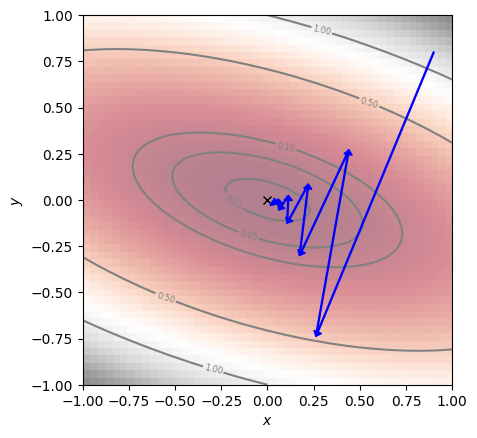

In [52]:
# Make contour plot
x = np.linspace(-r, r, 50)
y = np.linspace(-r, r, 50)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

contours = plt.contour(X, Y, Z, [0.01, 0.05, 0.1, 0.5, 1.], colors='grey')
plt.clabel(contours, inline=True, fontsize=6)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.imshow(Z, extent=[-r, r, -r, r], origin='lower', cmap='RdGy', alpha=0.5)

# Add optimum
plt.plot(0, 0, 'x', c='k')

# Plot gradient steps
for i in range(n_iter):
    plt.arrow(p_x[i], p_y[i], p_x[i+1]-p_x[i], p_y[i+1]-p_y[i], width=.005, head_width=.045, head_length=.025, length_includes_head=True, fc='b', ec='b', zorder=10)

Modify the example:

* Try different values, `eta = 0.01`, `eta = 0.1`, `eta = 0.5`, and `eta = 0.75`, and play with the number of steps.

* Add a momentum term to the update step

* Reimplement the model in PyTorch and use [automatic differentiation](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html) to compute the gradient.